# Maze Solver using Searching Algorithms

## Introduction
This notebook demonstrates a comprehensive approach to solving pathfinding problems in a 2D grid environment. Using a 9x9 maze, we compare several fundamental artificial intelligence search algorithms:

*   **Uninformed Search**: Breadth-First Search (BFS) and Depth-First Search (DFS).
*   **Informed Search**: Greedy Best-First Search and A* Search.

We will visualize not only the final path but also the exploration process (visited nodes) to understand how different heuristics and search strategies behave. The notebook concludes with an interactive Gradio interface to test these algorithms dynamically.

### Important: Movement Constraints

It is important to note that in this model, the agent can only move in **four directions**: **Up, Down, Left, and Right**.

**Diagonal movement is not allowed.**

This constraint is particularly significant for informed search algorithms (Greedy and A*). Our heuristics (Manhattan distance) and the neighbor detection logic are strictly designed for 4-way connectivity. If the priority queue were to consider diagonal paths, the heuristic values would stay artificially low compared to the actual cost, potentially leading to incorrect path calculations. By enforcing 4-way movement, we ensure that the exploration priority correctly follows the grid structure.

### 1. Setup and Imports
We begin by importing necessary libraries for UI generation (`gradio`), numerical operations (`numpy`), plotting (`matplotlib`), and search utilities (`heapq`, `collections`).

In [1]:
# Import required libraries
import gradio as gr
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from collections import deque
from heapq import heappush, heappop
from typing import NamedTuple, Iterator

### 2. Maze Generation Utility
This function creates a 9x9 grid, randomly places a specified number of obstacles, and defines the Start (0,0) and Goal (8,8) positions.

In [2]:
def generate_grid_maze(num_obstacles):
    size = 9
    # 0 = Path, 1 = Wall, 2 = Start, 3 = Goal
    grid = np.zeros((size, size))

    # Define Start and Goal
    start = (0, 0)
    goal = (8, 8)

    # Potential obstacle positions (excluding start and goal)
    candidates = [(r, c) for r in range(size) for c in range(size) if (r, c) != start and (r, c) != goal]

    # Ensure we don't pick more obstacles than available cells
    num_obstacles = min(num_obstacles, len(candidates))
    obstacles = random.sample(candidates, int(num_obstacles))

    for r, c in obstacles:
        grid[r, c] = 1

    grid[start] = 2
    grid[goal] = 3

    # Visualization
    fig, ax = plt.subplots(figsize=(5, 5))
    cmap = plt.cm.colors.ListedColormap(['white', 'black', 'green', 'red'])
    ax.imshow(grid, cmap=cmap)

    # Add grid lines
    ax.set_xticks(np.arange(-.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-.5, size, 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

    plt.title(f"9x9 Maze with {len(obstacles)} Obstacles")
    return fig

### 3. Data Structures and Models
We define `Position` and `SearchResult` as `NamedTuple`s for structured data. The `MazeModel` class handles neighbor detection logic, ensuring moves stay within bounds and avoid obstacles.

In [3]:
class Position(NamedTuple):
    row: int
    col: int

class SearchResult(NamedTuple):
    algorithm: str
    found: bool
    path: list[Position]
    visited_order: list[Position]
    edges: list[tuple[Position, Position]]
    nodes_expanded: int
    max_frontier: int
    elapsed_ms: float
    completeness: str
    optimality: str
    time_complexity: str
    space_complexity: str

In [4]:
class MazeModel:
    def __init__(self, maze_grid: np.ndarray, start: Position, goal: Position):
        self.maze_grid = maze_grid
        self.rows, self.cols = maze_grid.shape
        self.start = start
        self.goal = goal

        # Validate start and goal positions
        # Using -1 for path, 1 for wall based on logic in solve_and_visualize
        if not (0 <= start.row < self.rows and 0 <= start.col < self.cols):
            raise ValueError(f"Start position {start} is out of bounds.")
        if not (0 <= goal.row < self.rows and 0 <= goal.col < self.cols):
            raise ValueError(f"Goal position {goal} is out of bounds.")

    def neighbors(self, pos: Position) -> Iterator[tuple[str, Position]]:
        # Standard 4-connectivity for a grid maze
        possible_moves = [
            ('U', Position(pos.row - 1, pos.col)),
            ('D', Position(pos.row + 1, pos.col)),
            ('L', Position(pos.row, pos.col - 1)),
            ('R', Position(pos.row, pos.col + 1)),
        ]
        for direction, next_pos in possible_moves:
            if 0 <= next_pos.row < self.rows and \
               0 <= next_pos.col < self.cols and \
               self.maze_grid[next_pos.row, next_pos.col] == -1:
                yield direction, next_pos

### 4. Heuristics and Helpers
We implement Manhattan and Euclidean distance heuristics, along with a helper function to count surrounding walls used for tie-breaking in informed search algorithms.

In [5]:
class MazeSolver:
    @staticmethod
    def reconstruct_path(parent: dict[Position, Position | None],
                         goal: Position) -> list[Position]:
        path = []
        current = goal
        while current is not None:
            path.append(current)
            current = parent.get(current)
        return path[::-1]

    @staticmethod
    def manhattan(a: Position, b: Position) -> float:
        return abs(a.row - b.row) + abs(a.col - b.col)

    @staticmethod
    def euclidean(a: Position, b: Position) -> float:
        return ((a.row - b.row)**2 + (a.col - b.col)**2)**0.5

### 5. Breadth-First Search (BFS)
BFS explores nodes layer by layer, ensuring the shortest path in an unweighted grid. We optimize it by checking for visited nodes before adding them to the frontier.

In [6]:
def bfs_solve(model: MazeModel) -> SearchResult:
    """BFS: Filters visited nodes before adding to frontier."""
    start_t = time.perf_counter()
    q = deque([model.start])
    parent: dict[Position, Position | None] = {model.start: None}
    visited = {model.start}
    visited_order: list[Position] = []
    edges: list[tuple[Position, Position]] = []
    max_frontier = 1

    while q:
        max_frontier = max(max_frontier, len(q))
        cur = q.popleft()
        visited_order.append(cur)
        if cur == model.goal:
            break

        for _, nxt in model.neighbors(cur):
            # Optimization: Check visited before adding to queue
            if nxt not in visited:
                visited.add(nxt)
                parent[nxt] = cur
                edges.append((cur, nxt))
                q.append(nxt)

    path = MazeSolver.reconstruct_path(parent, model.goal)
    elapsed = (time.perf_counter() - start_t) * 1000
    return SearchResult(
        algorithm="BFS (Optimized)",
        found=bool(path),
        path=path,
        visited_order=visited_order,
        edges=edges,
        nodes_expanded=len(visited_order),
        max_frontier=max_frontier,
        elapsed_ms=elapsed,
        completeness="Complete",
        optimality="Optimal",
        time_complexity="O(V + E)",
        space_complexity="O(V)",
    )

### 6. Depth-First Search (DFS)
DFS explores as far as possible along each branch before backtracking. While not optimal for path length, it is a fundamental exhaustive search technique.

In [7]:
def dfs_solve(model: MazeModel) -> SearchResult:
    """Improved DFS: Filters visited nodes before pushing to stack."""
    start_t = time.perf_counter()
    stack = [model.start]
    parent: dict[Position, Position | None] = {model.start: None}
    visited = {model.start}
    visited_order: list[Position] = []
    edges: list[tuple[Position, Position]] = []
    max_frontier = 1

    while stack:
        max_frontier = max(max_frontier, len(stack))
        cur = stack.pop()
        visited_order.append(cur)
        if cur == model.goal:
            break

        # Process neighbors in reverse to maintain deterministic order in stack
        for _, nxt in reversed(list(model.neighbors(cur))):
            # Optimization: Check visited before adding to stack
            if nxt not in visited:
                visited.add(nxt)
                parent[nxt] = cur
                edges.append((cur, nxt))
                stack.append(nxt)

    path = MazeSolver.reconstruct_path(parent, model.goal)
    elapsed = (time.perf_counter() - start_t) * 1000
    return SearchResult(
        algorithm="DFS (Optimized)",
        found=bool(path),
        path=path,
        visited_order=visited_order,
        edges=edges,
        nodes_expanded=len(visited_order),
        max_frontier=max_frontier,
        elapsed_ms=elapsed,
        completeness="Complete",
        optimality="Not optimal",
        time_complexity="O(V + E)",
        space_complexity="O(V)",
    )

### 7. Greedy Best-First Search
Greedy search uses a heuristic to prioritize nodes that appear closest to the goal. It is fast but can be misled by obstacles as it does not consider the cost to reach the current node.

In [8]:
def greedy_best_first_solve(model: MazeModel, heuristic_name: str) -> SearchResult:
    """Greedy best-first with insertion order tie breaker."""
    heuristic = MazeSolver.manhattan if heuristic_name == "Manhattan" else MazeSolver.euclidean
    start_t = time.perf_counter()
    pq: list[tuple[float, int, Position]] = []
    # Use a tie-breaker id for stable sorting by insertion order
    tie_breaker_id = 0
    heappush(pq, (heuristic(model.start, model.goal), tie_breaker_id, model.start))
    parent: dict[Position, Position | None] = {model.start: None}
    visited = {model.start}
    visited_order: list[Position] = []
    edges: list[tuple[Position, Position]] = []
    max_frontier = 1

    while pq:
        max_frontier = max(max_frontier, len(pq))
        _, _, cur = heappop(pq)
        visited_order.append(cur)
        if cur == model.goal:
            break
        for _, nxt in model.neighbors(cur):
            if nxt in visited:
                continue
            visited.add(nxt)
            parent[nxt] = cur
            edges.append((cur, nxt))
            tie_breaker_id += 1 # Increment tie-breaker for new nodes
            heappush(pq, (heuristic(nxt, model.goal), tie_breaker_id, nxt))

    path = MazeSolver.reconstruct_path(parent, model.goal)
    elapsed = (time.perf_counter() - start_t) * 1000
    return SearchResult(
        algorithm=f"Greedy Best-First ({heuristic_name}) + Insertion Order Tie-break",
        found=bool(path),
        path=path,
        visited_order=visited_order,
        edges=edges,
        nodes_expanded=len(visited_order),
        max_frontier=max_frontier,
        elapsed_ms=elapsed,
        completeness="Complete",
        optimality="Not optimal",
        time_complexity="O(E log V)",
        space_complexity="O(V)",
    )

### 8. A* Search (Optimized)
A* combines the cost to reach a node (g) and the estimated cost to the goal (h). This implementation uses a multi-level tie-breaker: `f(n) -> walls -> h(n) -> g(n)` to decide between nodes with identical scores.

In [9]:
def a_star_solve(model: MazeModel, heuristic_name: str) -> SearchResult:
    """A* with multi-level tie breaker: f(n) -> h(n) -> g(n) -> insertion order."""
    heuristic = MazeSolver.manhattan if heuristic_name == "Manhattan" else MazeSolver.euclidean
    start_t = time.perf_counter()

    # PQ elements: (f, h, g, tie_breaker_id, pos)
    pq: list[tuple[float, float, float, int, Position]] = []
    tie_breaker_id = 0

    g_start = 0.0
    h_start = heuristic(model.start, model.goal)
    f_start = g_start + h_start
    heappush(pq, (f_start, h_start, g_start, tie_breaker_id, model.start))

    g_cost: dict[Position, float] = {model.start: 0.0}
    parent: dict[Position, Position | None] = {model.start: None}
    closed: set[Position] = set()
    visited_order: list[Position] = []
    edges: list[tuple[Position, Position]] = []
    max_frontier = 1

    while pq:
        max_frontier = max(max_frontier, len(pq))
        _, _, _, _, cur = heappop(pq)

        if cur in closed:
            continue
        closed.add(cur)
        visited_order.append(cur)

        if cur == model.goal:
            break

        for _, nxt in model.neighbors(cur):
            tentative_g = g_cost[cur] + 1.0
            if tentative_g < g_cost.get(nxt, float("inf")):
                g_cost[nxt] = tentative_g
                parent[nxt] = cur
                edges.append((cur, nxt))

                h_nxt = heuristic(nxt, model.goal)
                f_nxt = tentative_g + h_nxt
                tie_breaker_id += 1 # Increment tie-breaker for new nodes

                # Tie break: f -> h -> g -> tie_breaker_id
                heappush(pq, (f_nxt, h_nxt, tentative_g, tie_breaker_id, nxt))

    path = MazeSolver.reconstruct_path(parent, model.goal)
    elapsed = (time.perf_counter() - start_t) * 1000
    return SearchResult(
        algorithm=f"A* ({heuristic_name}) Optimized (f -> h -> g -> Insertion Order Tie-break)",
        found=bool(path),
        path=path,
        visited_order=visited_order,
        edges=edges,
        nodes_expanded=len(visited_order),
        max_frontier=max_frontier,
        elapsed_ms=elapsed,
        completeness="Complete",
        optimality="Optimal",
        time_complexity="O(E log V)",
        space_complexity="O(V)",
    )

### 9. Visualization and Integration
`visualize_search` draws the final state, highlighting visited nodes in Light Blue and the final path in Yellow. `solve_and_visualize` acts as the bridge between the UI and the search logic.

In [10]:
def visualize_search(maze_grid, result: SearchResult):
    size = maze_grid.shape[0]
    # 0=Path, 1=Wall, 2=Start, 3=Goal, 4=Visited, 5=Final Path
    vis_grid = maze_grid.copy().astype(float)

    # Mark visited (Blue)
    for pos in result.visited_order:
        if vis_grid[pos.row, pos.col] == 0: # Only color white path cells
            vis_grid[pos.row, pos.col] = 4

    # Mark path (Yellow)
    for pos in result.path:
        if vis_grid[pos.row, pos.col] not in [2, 3]: # Don't overwrite Start/Goal colors
            vis_grid[pos.row, pos.col] = 5

    fig, ax = plt.subplots(figsize=(6, 6))
    # Colors: White, Black, Green, Red, LightBlue, Yellow
    colors = ['white', 'black', 'green', 'red', '#add8e6', 'yellow']
    cmap = plt.cm.colors.ListedColormap(colors)
    ax.imshow(vis_grid, cmap=cmap, vmin=0, vmax=5)

    ax.set_xticks(np.arange(-.5, size, 1), minor=True)
    ax.set_yticks(np.arange(-.5, size, 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
    ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

    status = "Solved!" if result.found else "No Path Found"
    plt.title(f"{result.algorithm}\nNodes Expanded: {result.nodes_expanded} | {status}")
    return fig

def solve_and_visualize(num_obstacles, algorithm):
    size = 9
    start, goal = Position(0, 0), Position(8, 8)
    candidates = [Position(r, c) for r in range(size) for c in range(size) if (r, c) != start and (r, c) != goal]
    obstacles = random.sample(candidates, min(int(num_obstacles), len(candidates)))

    model_grid = np.full((size, size), -1)
    for r, c in obstacles: model_grid[r, c] = 1

    model = MazeModel(model_grid, start, goal)

    if "BFS" in algorithm: res = bfs_solve(model)
    elif "DFS" in algorithm: res = dfs_solve(model)
    elif "Greedy" in algorithm: res = greedy_best_first_solve(model, "Manhattan")
    else: res = a_star_solve(model, "Manhattan")

    display_grid = np.zeros((size, size))
    for r, c in obstacles: display_grid[r, c] = 1
    display_grid[start.row, start.col] = 2
    display_grid[goal.row, goal.col] = 3

    return visualize_search(display_grid, res)

In [11]:
def dashboard(num_obstacles, algorithm):
    size = 9
    start, goal = Position(0, 0), Position(8, 8)
    candidates = [Position(r, c) for r in range(size) for c in range(size) if (r, c) != start and (r, c) != goal]
    obstacles = random.sample(candidates, min(int(num_obstacles), len(candidates)))

    # Solving Logic
    model_grid = np.full((size, size), -1)
    for r, c in obstacles: model_grid[r, c] = 1
    model = MazeModel(model_grid, start, goal)

    if "BFS" in algorithm: res = bfs_solve(model)
    elif "DFS" in algorithm: res = dfs_solve(model)
    elif "Greedy" in algorithm: res = greedy_best_first_solve(model, "Manhattan")
    else: res = a_star_solve(model, "Manhattan")

    # Display Grids
    display_grid = np.zeros((size, size))
    for r, c in obstacles: display_grid[r, c] = 1
    display_grid[start.row, start.col] = 2
    display_grid[goal.row, goal.col] = 3

    solve_fig = visualize_search(display_grid, res)
    trans_fig = visualize_transitions(obstacles, size)

    return solve_fig, trans_fig

### 10. Gradio Interface
Finally, we launch the interactive interface that allows users to adjust obstacle density and select different algorithms to see their behavior in real-time.

In [12]:
demo = gr.Interface(
    fn=solve_and_visualize,
    inputs=[
        gr.Slider(0, 60, value=15, label="Obstacles"),
        gr.Dropdown(["BFS", "DFS", "Greedy (Manhattan)", "A* (Manhattan)"], label="Algorithm", value="A* (Manhattan)")
    ],
    outputs=gr.Plot(label="Maze Solution"),
    title="9x9 Maze Solver",
    description="Blue = Visited Nodes, Yellow = Optimal Path, Green = Start, Red = Goal."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://038777b636001396cc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Sample Solution with BFS

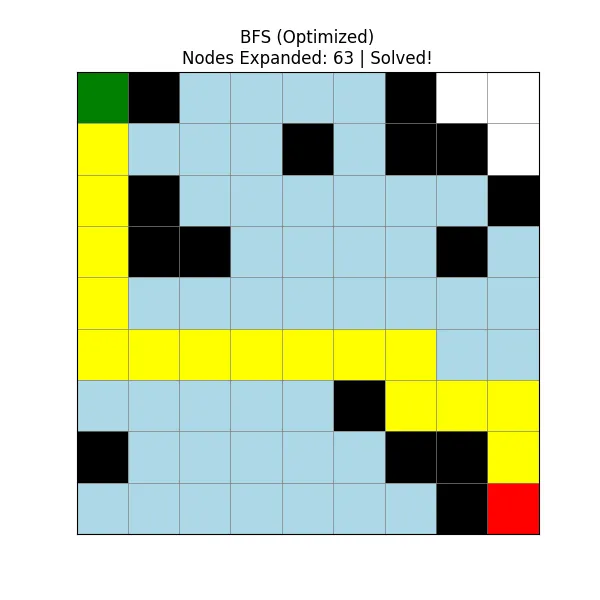

## Sample Solution with DFS

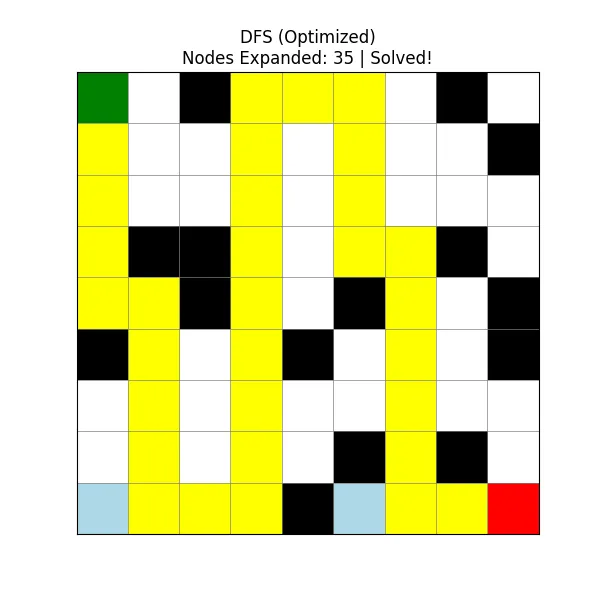

## Sample Solution with GBFS

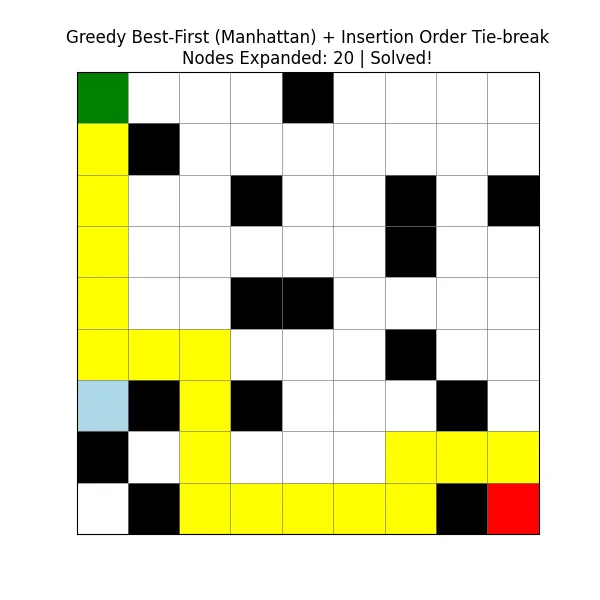

## Sample Solution with A*

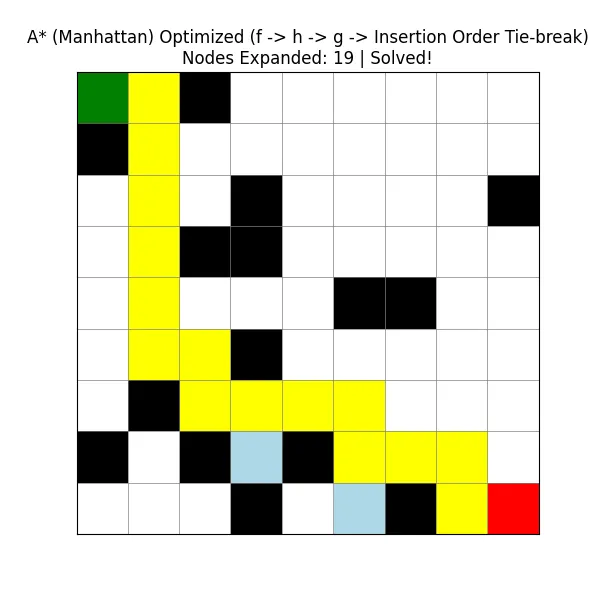